# VNP46A1 + VNP46A2 preprocessing diagnostics

This notebook prepares the downloaded Haiyan VNP46 GeoTIFF stacks for fast use in later notebooks. It deliberately separates a **five-day diagnostic run** from the full batch.

The workflow:

1. discovers all pre-event, post-event, and post-180-day stacks;
2. parses every band description into product, date, and variable;
3. verifies the grid, date coverage, band completeness, duplicates, and source dtypes;
4. normalizes documented fill values to `NaN` without rescaling the Earth Engine physical values;
5. writes and reopens the first five days for both products;
6. checks physical domains and exact round trips; and
7. exposes the full batch only behind an explicit confirmation token.

> The full cell is restartable. A date block is marked complete only after every variable in that block has been written. Leave `RUN_FULL_BATCH = False` while diagnosing.

In [1]:
from contextlib import ExitStack
from datetime import datetime, timezone
from pathlib import Path
import hashlib
import json
import re
import shutil
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import xarray as xr
import zarr
from IPython.display import Markdown, display
from numcodecs import Blosc
from tqdm.auto import tqdm

print(f'Rasterio {rasterio.__version__} | xarray {xr.__version__} | Zarr {zarr.__version__}')

Rasterio 1.4.3 | xarray 2024.7.0 | Zarr 2.18.2


/Users/S4135723/Library/CloudStorage/OneDrive-RMITUniversity/02 - CH2 - Disaster Impact and Recovery/blackmarble-disaster-recovery/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Paths are resolved correctly whether Jupyter starts in the repository root or in `notebooks/`. The diagnostic stores are intentionally separate from the full stores and from any older cache. Eight-day time chunks reduce small-file overhead while keeping memory use moderate.

In [2]:
def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / '.git').exists() and (candidate / 'datasets' / 'VNP46').is_dir():
            return candidate.resolve()
    raise FileNotFoundError('Could not find datasets/VNP46 from the current working directory.')

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'datasets' / 'VNP46'
DIAGNOSTIC_DIR = DATA_DIR / 'diagnostics'
PROCESSED_DIR = DATA_DIR / 'processed'
REPORT_DIR = DIAGNOSTIC_DIR / 'reports'

SAMPLE_DAYS = 5
TIME_CHUNK = 8
SPATIAL_CHUNK = 256
COMPRESSION_LEVEL = 5
PROCESSING_VERSION = 'vnp46-local-zarr-v1'

# Safe defaults: Run All performs only the five-day diagnostic.
RUN_SAMPLE = True
OVERWRITE_SAMPLE = True
RUN_FULL_BATCH = False
FULL_BATCH_CONFIRMATION = ''
REBUILD_FULL_CACHE = False

PRODUCTS = {
    'VNP46A1': {
        'pattern': 'Haiyan_VNP46A1_KeyBands_*.tif',
        'variables': [
            'DNB_At_Sensor_Radiance_500m', 'Sensor_Zenith', 'Sensor_Azimuth',
            'UTC_Time', 'Granule', 'QF_DNB', 'QF_Cloud_Mask',
            'Moon_Illumination_Fraction',
        ],
    },
    'VNP46A2': {
        'pattern': 'Haiyan_VNP46A2_AllBands_*.tif',
        'variables': [
            'DNB_BRDF_Corrected_NTL', 'DNB_Lunar_Irradiance',
            'Gap_Filled_DNB_BRDF_Corrected_NTL',
            'Latest_High_Quality_Retrieval', 'Mandatory_Quality_Flag',
            'QF_Cloud_Mask', 'Snow_Flag',
        ],
    },
}

for directory in [DIAGNOSTIC_DIR, PROCESSED_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Input folder:', DATA_DIR)

Project root: /Users/S4135723/Library/CloudStorage/OneDrive-RMITUniversity/02 - CH2 - Disaster Impact and Recovery/blackmarble-disaster-recovery
Input folder: /Users/S4135723/Library/CloudStorage/OneDrive-RMITUniversity/02 - CH2 - Disaster Impact and Recovery/blackmarble-disaster-recovery/datasets/VNP46


## Source inventory and hard gate

Every GeoTIFF band must have a description of the form `YYYY_MM_DD_variable`. The hard gate stops processing if a band cannot be parsed, a date-variable is duplicated or missing, grids differ, dates are discontinuous, or the A1/A2 date axes do not match. The notebook uses the dates actually present rather than assuming there are 560.

In [3]:
DESCRIPTION_RE = re.compile(r'^(?P<date>\d{4}_\d{2}_\d{2})_(?P<variable>.+)$')

def parse_description(description):
    match = DESCRIPTION_RE.match(str(description or ''))
    if match is None:
        return pd.NaT, None
    return pd.to_datetime(match.group('date'), format='%Y_%m_%d'), match.group('variable')

def relative_path(path):
    try:
        return str(Path(path).resolve().relative_to(PROJECT_ROOT))
    except ValueError:
        return str(Path(path).resolve())

band_rows, file_rows = [], []
for product, spec in PRODUCTS.items():
    files = sorted(DATA_DIR.glob(spec['pattern']))
    for file_priority, path in enumerate(files):
        with rasterio.open(path) as src:
            file_rows.append({
                'product': product, 'file': str(path.resolve()), 'name': path.name,
                'file_priority': file_priority, 'size_mb': path.stat().st_size / 1024**2,
                'modified_ns': path.stat().st_mtime_ns, 'width': src.width,
                'height': src.height, 'count': src.count, 'dtype': src.dtypes[0],
                'crs': src.crs.to_string() if src.crs else None,
                'transform': tuple(src.transform)[:6], 'bounds': tuple(src.bounds),
                'block_shape': src.block_shapes[0], 'compression': str(src.compression),
            })
            for band_index in range(1, src.count + 1):
                description = src.descriptions[band_index - 1]
                if description is None:
                    tags = src.tags(band_index)
                    description = tags.get('DESCRIPTION') or tags.get('NAME')
                date, variable = parse_description(description)
                band_rows.append({
                    'product': product, 'date': date, 'variable': variable,
                    'file': str(path.resolve()), 'file_name': path.name,
                    'band_index': band_index, 'description': description,
                })

file_inventory = pd.DataFrame(file_rows)
band_inventory = pd.DataFrame(band_rows)

def add_check(rows, name, passed, details, severity='FAIL'):
    rows.append({
        'check': name, 'status': 'PASS' if passed else severity, 'details': str(details),
    })

checks = []
for product, spec in PRODUCTS.items():
    product_files = file_inventory[file_inventory['product'].eq(product)]
    product_bands = band_inventory[band_inventory['product'].eq(product)]
    parsed = product_bands['date'].notna() & product_bands['variable'].notna()
    observed_variables = set(product_bands.loc[parsed, 'variable'])
    expected_variables = set(spec['variables'])
    duplicates = int(product_bands.loc[parsed].duplicated(['date', 'variable'], keep=False).sum())
    counts = product_bands.loc[parsed].groupby('date')['variable'].nunique()
    complete = bool(len(counts) and counts.eq(len(expected_variables)).all())
    dates = pd.DatetimeIndex(sorted(counts.index.unique()))
    expected_axis = pd.date_range(dates.min(), dates.max(), freq='D') if len(dates) else pd.DatetimeIndex([])
    add_check(checks, f'{product}: three source stacks', len(product_files) == 3, f'found {len(product_files)}')
    add_check(checks, f'{product}: descriptions parse', bool(parsed.all()), f'{int((~parsed).sum())} unparsed bands')
    add_check(checks, f'{product}: expected variables', observed_variables == expected_variables,
              f'observed {sorted(observed_variables)}')
    add_check(checks, f'{product}: no duplicate date-variable bands', duplicates == 0, f'{duplicates} duplicate rows')
    add_check(checks, f'{product}: complete daily band sets', complete,
              f'{len(dates)} dates; expected {len(expected_variables)} variables/date')
    add_check(checks, f'{product}: contiguous daily coverage', dates.equals(expected_axis),
              f'{dates.min().date()} to {dates.max().date()} ({len(dates)} dates)')

grid_columns = ['width', 'height', 'crs', 'transform', 'bounds']
grid_signatures = {tuple(row[column] if column not in {'transform', 'bounds'} else tuple(row[column])
                         for column in grid_columns) for _, row in file_inventory.iterrows()}
add_check(checks, 'All six stacks share one spatial grid', len(grid_signatures) == 1,
          f'{len(grid_signatures)} unique grid signature(s)')

dates_by_product = {
    product: pd.DatetimeIndex(sorted(band_inventory.loc[band_inventory['product'].eq(product), 'date'].dropna().unique()))
    for product in PRODUCTS
}
add_check(checks, 'A1 and A2 date axes match', dates_by_product['VNP46A1'].equals(dates_by_product['VNP46A2']),
          f"A1={len(dates_by_product['VNP46A1'])}, A2={len(dates_by_product['VNP46A2'])}")

inventory_checks = pd.DataFrame(checks)
display(inventory_checks)
display(file_inventory[['product', 'name', 'count', 'dtype', 'size_mb', 'width', 'height', 'compression']].round({'size_mb': 1}))

INVENTORY_GATE_PASSED = not inventory_checks['status'].eq('FAIL').any()
if not INVENTORY_GATE_PASSED:
    raise RuntimeError('Source inventory gate failed. Fix the FAIL rows before processing.')

common_dates = dates_by_product['VNP46A1']
band_lookup = band_inventory.set_index(['product', 'date', 'variable'])[['file', 'band_index']].to_dict('index')
print(f'Inventory gate passed: {len(common_dates)} contiguous dates from {common_dates.min().date()} to {common_dates.max().date()}.')

,check,status,details
0,VNP46A1: three source stacks,PASS,found 3
1,VNP46A1: descriptions parse,PASS,0 unparsed bands
2,VNP46A1: expected variables,PASS,"observed ['DNB_At_Sensor_Radiance_500m', 'Gran..."
3,VNP46A1: no duplicate date-variable bands,PASS,0 duplicate rows
4,VNP46A1: complete daily band sets,PASS,546 dates; expected 8 variables/date
5,VNP46A1: contiguous daily coverage,PASS,2013-05-12 to 2014-11-08 (546 dates)
6,VNP46A2: three source stacks,PASS,found 3
7,VNP46A2: descriptions parse,PASS,0 unparsed bands
8,VNP46A2: expected variables,PASS,"observed ['DNB_BRDF_Corrected_NTL', 'DNB_Lunar..."
9,VNP46A2: no duplicate date-variable bands,PASS,0 duplicate rows


,product,name,count,dtype,size_mb,width,height,compression
0,VNP46A1,Haiyan_VNP46A1_KeyBands_PostEvent_D0_D180.tif,1448,float32,407.9,473,674,Compression.lzw
1,VNP46A1,Haiyan_VNP46A1_KeyBands_PostEvent_D181_D365.tif,1480,float32,410.3,473,674,Compression.lzw
2,VNP46A1,Haiyan_VNP46A1_KeyBands_PreEvent_D180_D1.tif,1440,float32,397.2,473,674,Compression.lzw
3,VNP46A2,Haiyan_VNP46A2_AllBands_PostEvent_D0_D180.tif,1267,float32,228.8,473,674,Compression.lzw
4,VNP46A2,Haiyan_VNP46A2_AllBands_PostEvent_D181_D365.tif,1295,float32,208.2,473,674,Compression.lzw
5,VNP46A2,Haiyan_VNP46A2_AllBands_PreEvent_D180_D1.tif,1260,float32,196.1,473,674,Compression.lzw


Inventory gate passed: 546 contiguous dates from 2013-05-12 to 2014-11-08.


In [4]:
file_inventory.assign(file=file_inventory['file'].map(relative_path)).to_csv(REPORT_DIR / 'source_files.csv', index=False)
band_inventory.assign(file=band_inventory['file'].map(relative_path)).to_csv(REPORT_DIR / 'source_bands.csv', index=False)
inventory_checks.to_csv(REPORT_DIR / 'inventory_checks.csv', index=False)
print('Inventory reports:', REPORT_DIR)

Inventory reports: /Users/S4135723/Library/CloudStorage/OneDrive-RMITUniversity/02 - CH2 - Disaster Impact and Recovery/blackmarble-disaster-recovery/datasets/VNP46/diagnostics/reports


## Restartable Zarr writer

The stores keep source values as `float32` and convert fill values, non-finite cells, and values outside documented band domains to `NaN`. Source-domain anomalies are counted and reported before cleaning. No additional scale factor is applied because these GeoTIFFs already contain Earth Engine physical values. Each product gets its own store to avoid the shared `QF_Cloud_Mask` name colliding. Band domains follow the [official Earth Engine VNP46A2 catalogue](https://developers.google.com/earth-engine/datasets/catalog/NASA_VIIRS_002_VNP46A2) and VNP46A1 catalogue.

In [5]:
FILL_VALUES = {
    'DNB_At_Sensor_Radiance_500m': [65535], 'Sensor_Zenith': [-32768],
    'Sensor_Azimuth': [-32768], 'UTC_Time': [-999.9], 'Granule': [255],
    'QF_DNB': [65535], 'QF_Cloud_Mask': [65535],
    'Moon_Illumination_Fraction': [-32768],
    'DNB_BRDF_Corrected_NTL': [65535], 'DNB_Lunar_Irradiance': [65535],
    'Gap_Filled_DNB_BRDF_Corrected_NTL': [65535],
    'Latest_High_Quality_Retrieval': [255], 'Mandatory_Quality_Flag': [255],
    'Snow_Flag': [255],
}
DOMAIN_RULES = {
    'DNB_At_Sensor_Radiance_500m': (0, 6553.4, False),
    'Sensor_Zenith': (0, 90, False), 'Sensor_Azimuth': (-180, 180, False),
    'UTC_Time': (0, 24, False), 'Granule': (0, 254, True),
    'QF_DNB': (0, 65534, True), 'QF_Cloud_Mask': (0, 65534, True),
    'Moon_Illumination_Fraction': (0, 100, False),
    'DNB_BRDF_Corrected_NTL': (0, 6553.4, False),
    'DNB_Lunar_Irradiance': (0, 6553.4, False),
    'Gap_Filled_DNB_BRDF_Corrected_NTL': (0, 6553.4, False),
    'Latest_High_Quality_Retrieval': (0, 254, True),
    'Mandatory_Quality_Flag': (0, 3, True), 'Snow_Flag': (0, 1, True),
}

def normalize_array(values, variable, source_nodata=None):
    values = values.astype('float32', copy=False)
    invalid = ~np.isfinite(values) | np.isclose(values, -9999.0)
    if source_nodata is not None:
        invalid |= np.isclose(values, source_nodata)
    for fill in FILL_VALUES.get(variable, []):
        invalid |= np.isclose(values, fill)
    low, high, _ = DOMAIN_RULES[variable]
    invalid |= (values < low) | (values > high)
    result = values.copy()
    result[invalid] = np.nan
    return result

def source_domain_anomaly_count(values, variable, source_nodata=None):
    candidate = np.isfinite(values) & ~np.isclose(values, -9999.0)
    if source_nodata is not None:
        candidate &= ~np.isclose(values, source_nodata)
    for fill in FILL_VALUES.get(variable, []):
        candidate &= ~np.isclose(values, fill)
    low, high, _ = DOMAIN_RULES[variable]
    return int((candidate & ((values < low) | (values > high))).sum())

def product_manifest(product):
    rows = file_inventory[file_inventory['product'].eq(product)].sort_values('name')
    manifest = [
        {'path': relative_path(row.file), 'size': int(Path(row.file).stat().st_size),
         'modified_ns': int(Path(row.file).stat().st_mtime_ns)}
        for row in rows.itertuples(index=False)
    ]
    signature = hashlib.sha256(json.dumps(manifest, sort_keys=True).encode()).hexdigest()
    return manifest, signature

def create_or_open_store(store_path, product, dates, overwrite=False):
    store_path = Path(store_path)
    manifest, signature = product_manifest(product)
    grid = file_inventory[file_inventory['product'].eq(product)].iloc[0]
    variables = PRODUCTS[product]['variables']
    expected_shape = (len(dates), int(grid.height), int(grid.width))
    compressor = Blosc(cname='zstd', clevel=COMPRESSION_LEVEL, shuffle=Blosc.BITSHUFFLE)

    if store_path.exists() and not overwrite:
        group = zarr.open_group(str(store_path), mode='a')
        problems = []
        if group.attrs.get('processing_version') != PROCESSING_VERSION:
            problems.append('processing version differs')
        if group.attrs.get('source_signature') != signature:
            problems.append('source files differ')
        if list(group.attrs.get('variables', [])) != variables:
            problems.append('variable list differs')
        if 'completed' not in group or group['completed'].shape != (len(dates),):
            problems.append('completion tracker missing or wrong length')
        for variable in variables:
            if variable not in group or group[variable].shape != expected_shape:
                problems.append(f'{variable} missing or wrong shape')
        if problems:
            raise RuntimeError(f'Cannot safely resume {store_path}: ' + '; '.join(problems) +
                               '. Choose a new path or explicitly set REBUILD_FULL_CACHE=True.')
        return group

    store_path.parent.mkdir(parents=True, exist_ok=True)
    group = zarr.open_group(str(store_path), mode='w')
    transform = tuple(grid['transform'])
    x = transform[2] + (np.arange(int(grid.width)) + 0.5) * transform[0]
    y = transform[5] + (np.arange(int(grid.height)) + 0.5) * transform[4]
    group.attrs.update({
        'product': product, 'processing_version': PROCESSING_VERSION,
        'source_manifest': manifest, 'source_signature': signature,
        'variables': variables, 'crs': grid['crs'], 'transform': list(transform),
        'bounds': list(grid['bounds']), 'width': int(grid['width']), 'height': int(grid['height']),
        'nodata': 'NaN', 'scaling': 'Source physical values retained; no additional scaling.',
        'created_utc': datetime.now(timezone.utc).isoformat(),
    })
    time_array = group.create_dataset('time', data=np.asarray(dates, dtype='datetime64[ns]'),
                                      chunks=(min(512, len(dates)),), overwrite=True)
    time_array.attrs['_ARRAY_DIMENSIONS'] = ['time']
    x_array = group.create_dataset('x', data=x.astype('float64'), chunks=(min(1024, len(x)),), overwrite=True)
    y_array = group.create_dataset('y', data=y.astype('float64'), chunks=(min(1024, len(y)),), overwrite=True)
    x_array.attrs.update({'_ARRAY_DIMENSIONS': ['x'], 'standard_name': 'longitude', 'units': 'degrees_east'})
    y_array.attrs.update({'_ARRAY_DIMENSIONS': ['y'], 'standard_name': 'latitude', 'units': 'degrees_north'})
    crs_array = group.create_dataset('spatial_ref', shape=(), dtype='i1', overwrite=True)
    with rasterio.open(file_inventory[file_inventory['product'].eq(product)].iloc[0]['file']) as src:
        crs_wkt = src.crs.to_wkt() if src.crs else ''
    crs_array.attrs.update({'_ARRAY_DIMENSIONS': [], 'spatial_ref': crs_wkt, 'crs_wkt': crs_wkt,
                            'GeoTransform': ' '.join(map(str, transform))})
    completed = group.create_dataset('completed', shape=(len(dates),), chunks=(min(512, len(dates)),),
                                     dtype='bool', fill_value=False, overwrite=True)
    completed.attrs['_ARRAY_DIMENSIONS'] = ['time']
    for variable in variables:
        array = group.create_dataset(
            variable, shape=expected_shape, chunks=(min(TIME_CHUNK, len(dates)),
            min(SPATIAL_CHUNK, int(grid.height)), min(SPATIAL_CHUNK, int(grid.width))),
            dtype='float32', fill_value=np.nan, compressor=compressor, overwrite=True,
            write_empty_chunks=False,
        )
        array.attrs.update({'_ARRAY_DIMENSIONS': ['time', 'y', 'x'], 'grid_mapping': 'spatial_ref',
                            'source_product': product})
    return group

def array_statistics(product, date, variable, array):
    finite = array[np.isfinite(array)]
    row = {'product': product, 'date': pd.Timestamp(date), 'variable': variable,
           'valid_pixels': int(finite.size), 'total_pixels': int(array.size),
           'valid_pct': 100 * finite.size / array.size}
    for name, value in [('min', np.min), ('median', np.median), ('p99', lambda x: np.percentile(x, 99)), ('max', np.max)]:
        row[name] = float(value(finite)) if finite.size else np.nan
    return row

def process_to_store(product, dates, store_path, overwrite=False, collect_stats=False):
    dates = pd.DatetimeIndex(dates)
    group = create_or_open_store(store_path, product, dates, overwrite=overwrite)
    variables = PRODUCTS[product]['variables']
    completed = np.asarray(group['completed'][:], dtype=bool)
    rows = []
    source_paths = sorted(set(band_inventory.loc[band_inventory['product'].eq(product), 'file']))
    with ExitStack() as stack:
        sources = {path: stack.enter_context(rasterio.open(path)) for path in source_paths}
        progress = tqdm(total=len(dates), initial=int(completed.sum()), desc=f'{product} -> {Path(store_path).name}')
        for start in range(0, len(dates), TIME_CHUNK):
            stop = min(start + TIME_CHUNK, len(dates))
            if completed[start:stop].all():
                continue
            block = {variable: np.full((stop - start, group.attrs['height'], group.attrs['width']),
                                       np.nan, dtype='float32') for variable in variables}
            for local_index, date in enumerate(dates[start:stop]):
                records = [band_lookup[(product, pd.Timestamp(date), variable)] for variable in variables]
                source_files = {record['file'] for record in records}
                if len(source_files) != 1:
                    raise RuntimeError(f'{product} {date.date()} spans more than one source file.')
                source = sources[source_files.pop()]
                raw = source.read([int(record['band_index']) for record in records])
                for layer, variable in zip(raw, variables):
                    clean = normalize_array(layer, variable, source.nodata)
                    block[variable][local_index] = clean
                    if collect_stats:
                        row = array_statistics(product, date, variable, clean)
                        row['source_domain_anomaly_pixels'] = source_domain_anomaly_count(layer, variable, source.nodata)
                        rows.append(row)
            for variable in variables:
                group[variable][start:stop, :, :] = block[variable]
            group['completed'][start:stop] = True
            completed[start:stop] = True
            group.attrs['last_completed_date'] = str(dates[stop - 1].date())
            group.attrs['completed_dates'] = int(completed.sum())
            progress.update(stop - start)
        progress.close()
    return pd.DataFrame(rows), group

## Five-day diagnostic run

This processes the first five chronological dates for every band in both products. The stores are disposable diagnostic artifacts and are overwritten by default so that the test is repeatable.

In [6]:
sample_dates = common_dates[:SAMPLE_DAYS]
SAMPLE_STORES = {
    product: DIAGNOSTIC_DIR / f'{product.lower()}_first{SAMPLE_DAYS}.zarr'
    for product in PRODUCTS
}
sample_stats_frames = []
sample_seconds = {}

if RUN_SAMPLE:
    for product, store_path in SAMPLE_STORES.items():
        started = time.perf_counter()
        stats, group = process_to_store(product, sample_dates, store_path,
                                        overwrite=OVERWRITE_SAMPLE, collect_stats=True)
        sample_seconds[product] = time.perf_counter() - started
        sample_stats_frames.append(stats)
    sample_stats = pd.concat(sample_stats_frames, ignore_index=True)
    sample_stats.to_csv(REPORT_DIR / 'first5_value_statistics.csv', index=False)
    display(sample_stats.round(3))
else:
    sample_stats = pd.read_csv(REPORT_DIR / 'first5_value_statistics.csv', parse_dates=['date'])

print('Diagnostic dates:', ', '.join(date.strftime('%Y-%m-%d') for date in sample_dates))

VNP46A1 -> vnp46a1_first5.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

VNP46A1 -> vnp46a1_first5.zarr: 100%|██████████| 5/5 [00:45<00:00,  9.11s/it]

VNP46A1 -> vnp46a1_first5.zarr: 100%|██████████| 5/5 [00:45<00:00,  9.11s/it]

VNP46A2 -> vnp46a2_first5.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

VNP46A2 -> vnp46a2_first5.zarr: 100%|██████████| 5/5 [00:27<00:00,  5.54s/it]

VNP46A2 -> vnp46a2_first5.zarr: 100%|██████████| 5/5 [00:27<00:00,  5.54s/it]

,product,date,variable,valid_pixels,total_pixels,valid_pct,min,median,p99,max,source_domain_anomaly_pixels
0,VNP46A1,2013-05-12,DNB_At_Sensor_Radiance_500m,103801,318802,32.560,0.100,0.300,1.000,29.900,0
1,VNP46A1,2013-05-12,Sensor_Zenith,103801,318802,32.560,0.020,6.840,13.320,16.130,0
2,VNP46A1,2013-05-12,Sensor_Azimuth,103801,318802,32.560,-179.570,-80.340,94.250,179.920,0
3,VNP46A1,2013-05-12,UTC_Time,103801,318802,32.560,17.246,17.252,17.258,17.259,0
4,VNP46A1,2013-05-12,Granule,103801,318802,32.560,0.000,1.000,1.000,1.000,0
...,...,...,...,...,...,...,...,...,...,...,...
70,VNP46A2,2013-05-16,Gap_Filled_DNB_BRDF_Corrected_NTL,103801,318802,32.560,0.000,0.333,1.765,55.209,0
71,VNP46A2,2013-05-16,Latest_High_Quality_Retrieval,103801,318802,32.560,0.000,0.000,1.000,16.000,0
72,VNP46A2,2013-05-16,Mandatory_Quality_Flag,94814,318802,29.741,0.000,0.000,0.000,1.000,7
73,VNP46A2,2013-05-16,QF_Cloud_Mask,103801,318802,32.560,34.000,34.000,738.000,2282.000,0


Diagnostic dates: 2013-05-12, 2013-05-13, 2013-05-14, 2013-05-15, 2013-05-16


## Sample validation, round trip, and resource estimate

The round-trip test compares normalized source arrays with the values reopened from Zarr, including identical `NaN` locations. Domain checks catch accidental double scaling, retained fill values, corrupt angles/times, and non-integer quality flags.

,check,status,details
0,VNP46A1: all sample dates marked complete,PASS,5/5 complete
1,VNP46A1 DNB_At_Sensor_Radiance_500m: source do...,PASS,0 out-of-domain source pixels normalized to NaN
2,VNP46A1 DNB_At_Sensor_Radiance_500m: physical ...,PASS,"0 values outside [0, 6553.4]"
3,VNP46A1 Sensor_Zenith: source domain,PASS,0 out-of-domain source pixels normalized to NaN
4,VNP46A1 Sensor_Zenith: physical domain,PASS,"0 values outside [0, 90]"
5,VNP46A1 Sensor_Azimuth: source domain,PASS,0 out-of-domain source pixels normalized to NaN
6,VNP46A1 Sensor_Azimuth: physical domain,PASS,"0 values outside [-180, 180]"
7,VNP46A1 UTC_Time: source domain,PASS,0 out-of-domain source pixels normalized to NaN
8,VNP46A1 UTC_Time: physical domain,PASS,"0 values outside [0, 24]"
9,VNP46A1 Granule: source domain,PASS,0 out-of-domain source pixels normalized to NaN


,sample_store_mb,estimated_full_store_gb,free_disk_gb,sample_elapsed_seconds,estimated_full_minutes,disk_headroom_ok
0,5.68,0.7,751.1,73.66,134.06,True


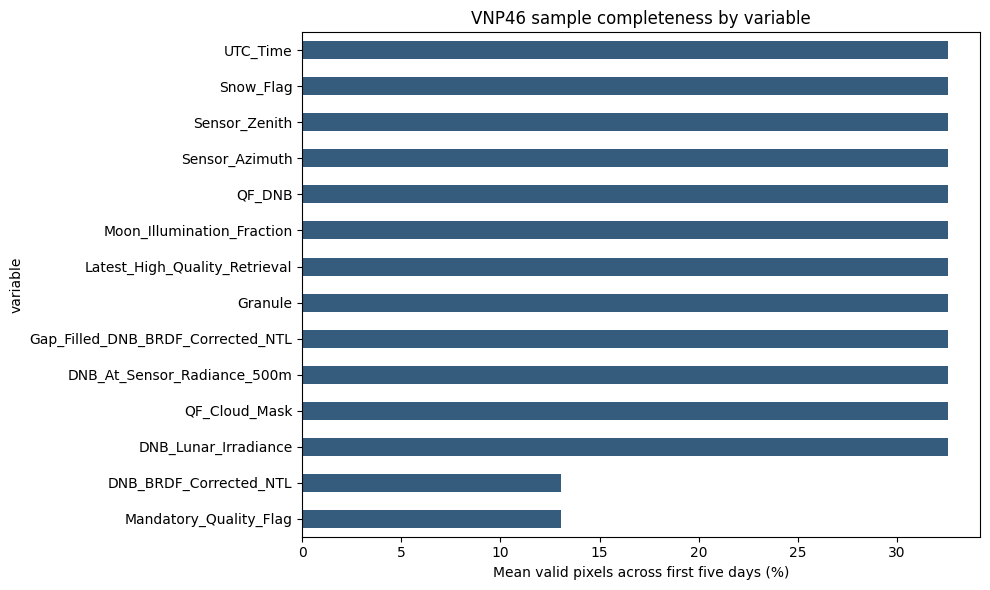

Five-day diagnostic gate PASSED.


In [7]:
sample_check_rows = []
for product, store_path in SAMPLE_STORES.items():
    group = zarr.open_group(str(store_path), mode='r')
    completed_ok = bool(np.asarray(group['completed'][:]).all())
    add_check(sample_check_rows, f'{product}: all sample dates marked complete', completed_ok,
              f"{int(np.asarray(group['completed'][:]).sum())}/{len(sample_dates)} complete")
    source_paths = sorted(set(band_inventory.loc[band_inventory['product'].eq(product), 'file']))
    with ExitStack() as stack:
        sources = {path: stack.enter_context(rasterio.open(path)) for path in source_paths}
        for date_index, date in enumerate(sample_dates):
            variables = PRODUCTS[product]['variables']
            records = [band_lookup[(product, pd.Timestamp(date), variable)] for variable in variables]
            source_files = {record['file'] for record in records}
            if len(source_files) != 1:
                raise RuntimeError(f'{product} {date.date()} spans more than one source file.')
            source = sources[source_files.pop()]
            raw = source.read([int(record['band_index']) for record in records])
            for layer, variable in zip(raw, variables):
                expected = normalize_array(layer, variable, source.nodata)
                observed = group[variable][date_index, :, :]
                equal = np.array_equal(expected, observed, equal_nan=True)
                if not equal:
                    add_check(sample_check_rows, f'{product} {date.date()} {variable}: exact round trip',
                              False, 'source and reopened Zarr values differ')
    for variable in PRODUCTS[product]['variables']:
        source_anomalies = int(sample_stats.loc[(sample_stats['product'].eq(product)) &
                                  (sample_stats['variable'].eq(variable)),
                                  'source_domain_anomaly_pixels'].sum())
        add_check(sample_check_rows, f'{product} {variable}: source domain', source_anomalies == 0,
                  f'{source_anomalies} out-of-domain source pixels normalized to NaN', severity='WARN')
        values = group[variable][:]
        finite = values[np.isfinite(values)]
        low, high, integer_expected = DOMAIN_RULES[variable]
        outside = int(((finite < low) | (finite > high)).sum()) if finite.size else 0
        noninteger = int((~np.isclose(finite, np.rint(finite), atol=1e-5)).sum()) if finite.size and integer_expected else 0
        add_check(sample_check_rows, f'{product} {variable}: physical domain', outside == 0,
                  f'{outside} values outside [{low}, {high}]')
        if integer_expected:
            add_check(sample_check_rows, f'{product} {variable}: integer-coded', noninteger == 0,
                      f'{noninteger} finite non-integer values')
    add_check(sample_check_rows, f'{product}: exact source-to-Zarr round trips',
              not any(row['status'] == 'FAIL' and 'round trip' in row['check'] for row in sample_check_rows),
              f'{len(sample_dates)} dates checked across all variables')

sample_checks = pd.DataFrame(sample_check_rows)
sample_checks.to_csv(REPORT_DIR / 'first5_checks.csv', index=False)
display(sample_checks)
SAMPLE_GATE_PASSED = not sample_checks['status'].eq('FAIL').any()

def directory_bytes(path):
    return sum(item.stat().st_size for item in Path(path).rglob('*') if item.is_file())

actual_sample_bytes = sum(directory_bytes(path) for path in SAMPLE_STORES.values())
estimated_full_bytes = int(actual_sample_bytes / len(sample_dates) * len(common_dates) * 1.15)
free_bytes = shutil.disk_usage(PROCESSED_DIR).free
elapsed = sum(sample_seconds.values()) if sample_seconds else np.nan
estimated_minutes = elapsed / len(sample_dates) * len(common_dates) / 60 if np.isfinite(elapsed) else np.nan
resource_summary = pd.DataFrame([{
    'sample_store_mb': actual_sample_bytes / 1024**2,
    'estimated_full_store_gb': estimated_full_bytes / 1024**3,
    'free_disk_gb': free_bytes / 1024**3,
    'sample_elapsed_seconds': elapsed, 'estimated_full_minutes': estimated_minutes,
    'disk_headroom_ok': free_bytes > estimated_full_bytes * 1.25,
}])
resource_summary.to_csv(REPORT_DIR / 'resource_estimate.csv', index=False)
display(resource_summary.round(2))
if not bool(resource_summary.loc[0, 'disk_headroom_ok']):
    warnings.warn('Estimated full output leaves less than 25% disk headroom. Change PROCESSED_DIR before batching.')

coverage = sample_stats.pivot_table(index=['product', 'date'], columns='variable', values='valid_pct')
coverage.mean().sort_values().plot.barh(figsize=(10, 6), color='#355c7d')
plt.xlabel('Mean valid pixels across first five days (%)')
plt.title('VNP46 sample completeness by variable')
plt.tight_layout()
plt.show()

if not SAMPLE_GATE_PASSED:
    raise RuntimeError('Five-day sample gate failed. Do not run the full batch.')
print('Five-day diagnostic gate PASSED.')

## Full restartable batch (deliberately disabled)

Only after reviewing the tables and plot above, set `RUN_FULL_BATCH = True` and set `FULL_BATCH_CONFIRMATION` to the token printed below. Re-run the configuration cell and this cell.

The writer skips completed blocks. If interrupted during a block, that block remains unmarked and is safely rewritten on the next run. `REBUILD_FULL_CACHE = True` recreates the target stores, so use it only when you intentionally want to discard their contents. You can work in another notebook at the same time by selecting a separate kernel.

In [8]:
EXPECTED_CONFIRMATION = f'RUN_ALL_{len(common_dates)}_DAYS'
FULL_STORES = {
    product: PROCESSED_DIR / f'{product.lower()}_daily.zarr'
    for product in PRODUCTS
}
print('Required confirmation token:', EXPECTED_CONFIRMATION)

if RUN_FULL_BATCH:
    if not (INVENTORY_GATE_PASSED and SAMPLE_GATE_PASSED):
        raise RuntimeError('Inventory and five-day diagnostic gates must pass first.')
    if FULL_BATCH_CONFIRMATION != EXPECTED_CONFIRMATION:
        raise RuntimeError(f'Set FULL_BATCH_CONFIRMATION exactly to {EXPECTED_CONFIRMATION!r}.')
    if not bool(resource_summary.loc[0, 'disk_headroom_ok']):
        raise RuntimeError('Insufficient 25% disk headroom for the estimated batch output.')
    for product, store_path in FULL_STORES.items():
        process_to_store(product, common_dates, store_path,
                         overwrite=REBUILD_FULL_CACHE, collect_stats=False)
        group = zarr.open_group(str(store_path), mode='r')
        if not np.asarray(group['completed'][:]).all():
            raise RuntimeError(f'{product} batch ended without all dates complete.')
    print('Full batch complete and verified:', PROCESSED_DIR)
else:
    print('Full batch is OFF. Review diagnostics, then opt in explicitly if they look correct.')

Required confirmation token: RUN_ALL_546_DAYS
Full batch is OFF. Review diagnostics, then opt in explicitly if they look correct.


## Use the cache in the next notebook

Open with `chunks=None` because this environment does not require Dask. The `completed` coordinate is an integrity check, not a science variable. Keep A1 acquisition-condition variables and A2 science/quality variables separate, joining them by `time`, `x`, and `y` only when needed.

In [9]:
# This example uses the five-day outputs now; switch SAMPLE_STORES to FULL_STORES after batching.
a1 = xr.open_zarr(SAMPLE_STORES['VNP46A1'], chunks=None, consolidated=False)
a2 = xr.open_zarr(SAMPLE_STORES['VNP46A2'], chunks=None, consolidated=False)
assert bool(a1['completed'].all()) and bool(a2['completed'].all())
display(a1)
display(a2)

# Example lazy-on-disk selections (loaded only when .values, .compute(), or plotting is requested):
sample_radiance = a2['DNB_BRDF_Corrected_NTL'].sel(time=sample_dates[0])
print('Selected A2 layer:', sample_radiance.shape, sample_radiance.dtype)

<xarray.Dataset> Size: 51MB
Dimensions:                      (time: 5, y: 674, x: 473)
Coordinates:
  * time                         (time) datetime64[ns] 40B 2013-05-12 ... 201...
  * x                            (x) float64 4kB 124.0 124.0 ... 126.0 126.0
  * y                            (y) float64 5kB 12.7 12.69 ... 9.898 9.894
Data variables:
    DNB_At_Sensor_Radiance_500m  (time, y, x) float32 6MB ...
    Granule                      (time, y, x) float32 6MB ...
    Moon_Illumination_Fraction   (time, y, x) float32 6MB ...
    QF_Cloud_Mask                (time, y, x) float32 6MB ...
    QF_DNB                       (time, y, x) float32 6MB ...
    Sensor_Azimuth               (time, y, x) float32 6MB ...
    Sensor_Zenith                (time, y, x) float32 6MB ...
    UTC_Time                     (time, y, x) float32 6MB ...
    completed                    (time) object 40B True True True True True
    spatial_ref                  float32 4B ...
Attributes: (12/15)
    bounds:               [123.99999951360002, 9.891666762839996, 125.9708328...
    completed_dates:      5
    created_utc:          2026-07-22T02:12:22.758071+00:00
    crs:                  EPSG:4326
    height:               674
    last_completed_date:  2013-05-16
    ...                   ...
    scaling:              Source physical values retained; no additional scal...
    source_manifest:      [{'modified_ns': 1784616570591213940, 'path': 'data...
    source_signature:     cff4eed41bdd470e1d6a30736a2fe60e6d74b2fba567797a0e6...
    transform:            [0.00416666666, 0.0, 123.99999951360002, 0.0, -0.00...
    variables:            ['DNB_At_Sensor_Radiance_500m', 'Sensor_Zenith', 'S...
    width:                473

<xarray.Dataset> Size: 45MB
Dimensions:                            (time: 5, y: 674, x: 473)
Coordinates:
  * time                               (time) datetime64[ns] 40B 2013-05-12 ....
  * x                                  (x) float64 4kB 124.0 124.0 ... 126.0
  * y                                  (y) float64 5kB 12.7 12.69 ... 9.894
Data variables:
    DNB_BRDF_Corrected_NTL             (time, y, x) float32 6MB ...
    DNB_Lunar_Irradiance               (time, y, x) float32 6MB ...
    Gap_Filled_DNB_BRDF_Corrected_NTL  (time, y, x) float32 6MB ...
    Latest_High_Quality_Retrieval      (time, y, x) float32 6MB ...
    Mandatory_Quality_Flag             (time, y, x) float32 6MB ...
    QF_Cloud_Mask                      (time, y, x) float32 6MB ...
    Snow_Flag                          (time, y, x) float32 6MB ...
    completed                          (time) object 40B True True ... True True
    spatial_ref                        float32 4B ...
Attributes: (12/15)
    bounds:               [123.99999951360002, 9.891666762839996, 125.9708328...
    completed_dates:      5
    created_utc:          2026-07-22T02:13:08.543610+00:00
    crs:                  EPSG:4326
    height:               674
    last_completed_date:  2013-05-16
    ...                   ...
    scaling:              Source physical values retained; no additional scal...
    source_manifest:      [{'modified_ns': 1784680040998625068, 'path': 'data...
    source_signature:     cf4d28b0bb3634f30840579926018b6a9c8f431e5f9a648cb3f...
    transform:            [0.00416666666, 0.0, 123.99999951360002, 0.0, -0.00...
    variables:            ['DNB_BRDF_Corrected_NTL', 'DNB_Lunar_Irradiance', ...
    width:                473

Selected A2 layer: (674, 473) float32
